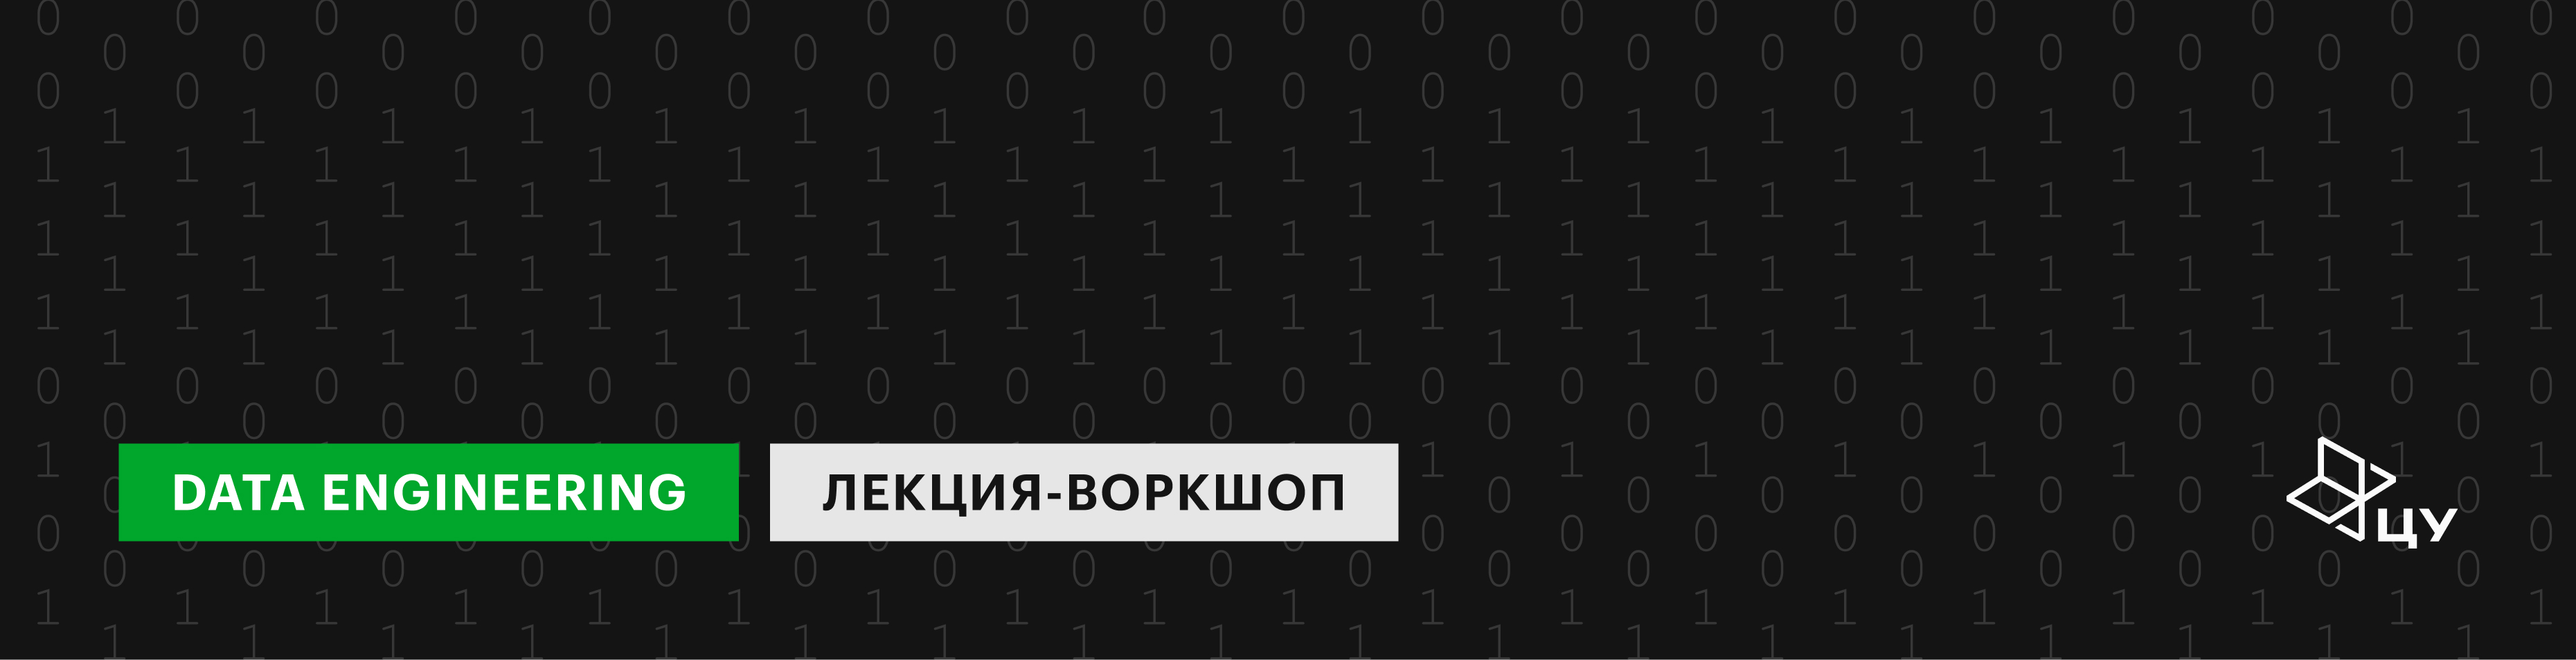

# Воркшоп по теме Введение в инженерию данных. Что делать, если вместо таблиц - файлы


Практические примеры по теме лекции.


In [ ]:
import os,requests,time,pandas as pd;u="http://sql-exercise.sql-exercise-prod.svc.cluster.local/"
f="py_workshop.py";
if os.path.exists(f):os.remove(f)
if not os.path.exists(f):
    r=requests.get(u+"get_py_workshop");r.status_code==200 and open(f,"wb").write(r.content) and time.sleep(1)
from py_workshop import *
pd.set_option("display.max_columns", None);pd.set_option("display.width", 2000);pd.set_option("display.max_colwidth", None);pd.set_option("display.max_rows", None)
runner.set_url(u);runner.logon();schema_name = runner.user_schema;config=runner.get_config()
runner.course = 'de'
runner.material( 'de_intro_workshop', course_launch='de_2026_fall_cu')

Начнём с установки зависимостей.

In [ ]:
%pip install duckdb-extensions duckdb-extension-httpfs
import yaml
from duckdb_extensions import import_extension
import duckdb
import pandas as pd

import_extension("httpfs")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", None)     # показывать все строки

## Пара слов о S3-like хранилищах

Данные могут жить в своем специализированном слое отдельно от инструментов обработки. Для этого существуют различные форматы данных. В качестве основной мотивации здесь выступает решение проблемы масштабирования, которая неизбежно возникает при работе с большими объёмами данных.


Мы используем S3-like-хранилище в курсе, потому что это один из самых распространённых способов хранения данных в современных data-платформах. В реальных проектах данные часто сначала попадают не в базу данных, а в объектное хранилище: в виде CSV, JSON, Parquet, логов, выгрузок из внешних систем или промежуточных файлов.


На этом воркшопе мы познакомимся с тем, как устроено файловое хранилище, как читать и записывать данные без классической СУБД. 


**В файловом хранилище S3 есть несколько важных особенностей.**

1. Данные хранятся как объекты, а не как строки таблицы. Один объект обычно соответствует файлу: CSV, JSON, Parquet, архиву или другому бинарному файлу.

2. Объекты лежат в **бакетах**. Бакет можно воспринимать как верхний уровень хранения, внутри которого размещаются файлы проекта или датасета.

3. У объекта есть ключ. Ключ похож на путь к файлу, например `data/flights/2026-01-01/flights.csv.gz`, но технически это не папка, а строковый идентификатор объекта.

4. «Папки» в S3 условные. Если несколько ключей начинаются одинаково, интерфейсы (в нашем курсе не используется) показывают их как директории, но отдельной файловой папки может не существовать.

5. S3 хорошо подходит для хранения больших наборов данных. Данные можно складывать по датам, источникам или типам событий, а потом читать только нужную часть.

6. S3 не выполняет SQL-запросы само по себе. Для анализа поверх файлов нужны инструменты обработки: DuckDB, Spark, ClickHouse, Python или другие движки.

7. Формат файлов важен. CSV проще читать человеку, но Parquet обычно эффективнее для аналитики, потому что хранит данные по колонкам и лучше подходит для больших объёмов.

8. Для доступа к объектам нужны права и параметры подключения: **endpoint**, **bucket**, **ключ объекта**, **access key** и **secret key**. 

In [ ]:
# Общий бакет, к которому у всех есть доступ
common_bucket = "culab-files-prod"

# Адрес подключения к S3
s3_endpoint_url = "https://storage.yandexcloud.net"
s3_endpoint_host = s3_endpoint_url.replace("https://", "").replace("http://", "")

# Пример. Префикс для файлов с данными
flight_data_prefix = "files/public/data_engineering/data_streams/ds_flights_usdom_24"

# Пример. Дата для выборки
flight_date = "2025-12-20"

# Пример. Ключ файла в хранилище S3
flight_file_key = f"{flight_data_prefix}/{flight_date}/flights_{flight_date}.csv.gz"

con = duckdb.connect()
con.execute("LOAD httpfs;")


#    Код вида !команда позволяет выполнять команды терминала 
#    При этом можно использовать переменных python внутри таких команд, а также присваивать результат

## Цель воркшопа
Познакомиться с тем, как работать с данными в облачном хранилище:
- загружать,
- анализировать,
- сохранять.

Нам доступен источник данных с реальными данными без учета отменённых рейсов.

## Сценарий: анализ задержек авиарейсов

**Задача:** мы работаем в авиакомпании и хотим понять, какие маршруты чаще всего задерживаются. Данные хранятся в S3, нам нужно их скачать, проанализировать и найти топ-5 самых проблемных маршрутов.


## Часть 1: Знакомство с данными через AWS CLI

Дата-инженер работает с большими объемами данных, которые хранятся в облаке. Первый шаг — посмотреть, какие данные у нас есть.


Наши файлы хранятся в бакете `culab-files-prod` с префиксом `files/public/data_engineering/data_streams/ds_flights_usdom_24/`.

Для доступа к данным нужны ключи от общего бакета. В нашей среде они обозначены `s3_public`.

### Шаг 1.1: просмотр файлов в S3

**Использование команд aws cli**

In [ ]:
# Настройка профиля common — для чтения общего бакета
# config['s3_public'] должен быть заполнен нужными параметрами доступа. Можно проверить содержимое этого поля

# Установка aws_access_key_id
!aws configure set aws_access_key_id "{config['s3_public']['login']}" --profile common

# Установка aws_secret_access_key
!aws configure set aws_secret_access_key "{config['s3_public']['password']}" --profile common

# Задаём регион
!aws configure set region "ru-central1" --profile common

In [ ]:
# Посмотрим, какие файлы есть в нашем хранилище. Выводим 5 записей.

files=!aws s3 ls s3://{common_bucket}/{flight_data_prefix}/ --recursive --endpoint={s3_endpoint_url} --profile=common

files[-5:] # 5 файлов с конца списка

**Пояснения:** мы используем AWS CLI (командную строку) для работы с облачным хранилищем S3. Это как `ls` в терминале, но для облака.

Теперь мы видим список CSV-файлов с данными о рейсах за разные даты.

### Шаг 1.2: скачивание одного файла для анализа

In [ ]:
# Выбираем последний доступный файл
last_file = files[-1]

flight_file_key=last_file.split()[3]

In [ ]:

# Проверка существования
!aws s3 ls s3://{common_bucket}/{flight_file_key} --endpoint={s3_endpoint_url} --profile=common

In [ ]:
# Скачаем файл за последнюю дату для изучения

# Пример полного пути: s3://culab-files-prod/files/public/data_engineering/data_streams/ds_flights_usdom_24/2025-12-20/flights_2025-12-20.csv.gz

result=!aws s3 cp s3://{common_bucket}/{flight_file_key} flights_export.csv.gz --endpoint={s3_endpoint_url} --profile common

result


**Пояснения:** копируем файл из облака на локальный компьютер для работы.

Файл `flights_export.csv.gz` теперь находится рядом с данным ноутбуком.


## Часть 2: анализ данных через DuckDB

### Что такое DuckDB?
DuckDB — это инструмент, который позволяет работать с файлами как с таблицами в базе данных. Можно писать SQL-запросы к CSV-файлам!

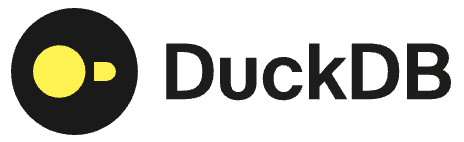

### Шаг 2.1: подключение и знакомство с данными

In [ ]:
# Создаём подключение к DuckDB
con = duckdb.connect()

# Читаем CSV-файл как таблицу
df = con.execute("""
    SELECT 
        Origin,
        Dest,
        FlightDate,
        DepDelayMinutes,
        ArrDelayMinutes,
        WeatherDelay
    FROM read_csv_auto('flights_export.csv.gz')
    LIMIT 10
""").df()

print("Первые 10 строк:")
print(df)

**Пояснения:** DuckDB читает сжатый CSV-файл и позволяет работать с ним через привычный SQL-интерфейс. Другие форматы тоже поддерживаются. Мы выбрали часть столбцов и считали только первые 10 строк.

Видим структуру данных — аэропорты отправления/прибытия, даты и задержки.

### Шаг 2.2: простой анализ — сколько всего рейсов?

In [ ]:
# Подсчитаем общее количество рейсов в файле
result = con.execute("""
    SELECT 
        COUNT(*) as total_flights
    FROM 
        read_csv_auto('flights_export.csv.gz')
""").df()

print(f"Всего рейсов в файле: {result['total_flights'].iloc[0]}")

**Пояснения:** используем SQL для подсчёта строк в файле.

Узнаем, сколько рейсов в нашем файле.

### Шаг 2.3: находим пять самых задерживаемых маршрутов

In [ ]:
# На каких направлениях наблюдается наибольшее количество задержек?
top_delayed = con.execute("""
    SELECT 
        Origin,
        Dest,
        COUNT(*) as total_flights,
        SUM(CASE WHEN DepDelayMinutes > 15 THEN 1 ELSE 0 END) as delayed_flights,
        ROUND(100.0 * SUM(CASE WHEN DepDelayMinutes > 15 THEN 1 ELSE 0 END) / COUNT(*), 2) as delay_percentage,
        AVG(DepDelayMinutes) as avg_delay_minutes
    FROM 
        read_csv_auto('flights_export.csv.gz')
    WHERE 
        DepDelayMinutes IS NOT NULL
    GROUP BY Origin, Dest
    HAVING COUNT(*) >= 10  -- только маршруты с минимум 10 рейсами
    ORDER BY delay_percentage DESC
    LIMIT 5
""").df()

print("\n🏆 Топ-5 самых проблемных маршрутов:")
print(top_delayed)

**Пояснения:** 
- группируем рейсы по направлениям (Origin → Dest);
- считаем процент задержек (задержка > 15 минут);
- сортируем по проценту задержек;
- показываем топ-5.

Получаем список маршрутов, которые задерживаются чаще всего.

In [ ]:
# А ещё можно читать данные без скачивания

# Настраиваем доступ к S3 в DuckDb
con.execute(f"""
    SET s3_region='ru-central1';
    SET s3_endpoint='{s3_endpoint_host}';
    SET s3_access_key_id='{config['s3_public']['login']}';
    SET s3_secret_access_key='{config['s3_public']['password']}';
    SET s3_use_ssl=true;
    SET s3_url_style='path'; 
""")

In [ ]:
# Альтернативный вариант с чтением данных из облака 

top_delayed = con.execute(f"""
    SELECT 
        Origin,
        Dest,
        COUNT(*) as total_flights,
        SUM(CASE WHEN DepDelayMinutes > 15 THEN 1 ELSE 0 END) as delayed_flights,
        ROUND(100.0 * SUM(CASE WHEN DepDelayMinutes > 15 THEN 1 ELSE 0 END) / COUNT(*), 2) as delay_percentage,
        AVG(DepDelayMinutes) as avg_delay_minutes
    FROM 
        read_csv_auto('s3://{common_bucket}/{flight_file_key}')
    WHERE 
        DepDelayMinutes IS NOT NULL
    GROUP BY Origin, Dest
    HAVING COUNT(*) >= 10  -- только маршруты с минимум 10 рейсами
    ORDER BY delay_percentage DESC
    LIMIT 5
""").df()

print("\n🏆 Топ-5 самых проблемных маршрутов:")
print(top_delayed)



## Часть 3: работа с данными через Python (boto3)

### Что такое boto3?

Ещё один способ работы с данными в S3 — через программный код Python.

boto3 — это Python-библиотека для работы с AWS-сервисами. Позволяет выполнять все действия с объектами S3 через код.

### Шаг 3.1: подключение к S3 через boto3

In [ ]:
import boto3

# Подключаемся к S3
access_key=config['s3_public']['login']
secret_key=config['s3_public']['password']

s3_client = boto3.client(
    's3',
    endpoint_url=s3_endpoint_url,
    aws_access_key_id=access_key,
    aws_secret_access_key=secret_key
)

print("✅ Подключение к S3 установлено")

**Пояснения:** создаём клиент для работы с S3 через Python.

### Шаг 3.2: список файлов через boto3

In [ ]:
# Получаем список файлов в папке
response = s3_client.list_objects_v2(
    Bucket=common_bucket,
    Prefix=f'{flight_data_prefix}/'
)

print("Доступные файлы:")
for obj in response.get('Contents', [])[-5:]:  # показываем наиболее актуальные файлы
    print(f"  - {obj['Key']} ({obj['Size']} bytes)")

**Пояснения:** используем boto3 вместо AWS CLI для получения списка файлов.

Видим те же файлы, что и через CLI, но теперь можем обработать их программно.

### Шаг 3.3: скачивание файла через boto3

In [ ]:
# Скачиваем файл
s3_client.download_file(
    Bucket=common_bucket,
    Key=flight_file_key,
    Filename='flights_boto3.csv.gz'
)

print("✅ Файл скачан через boto3")

**Пояснения:** скачиваем файл без использования команд терминала.

## Итоги текущего воркшопа

Мы разобрали три базовых способа работы с файлами в S3.

1. **AWS CLI** — просмотр и скачивание объектов через командную строку.
2. **DuckDB** — SQL-анализ CSV-файлов без загрузки в отдельную базу данных.
3. **boto3** — программная работа с S3 из Python.

# QR-код для сбора обратной связи

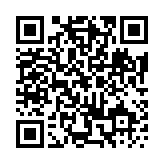